# Eksperyment 7: Porównanie opisów dla tematycznych kategorii MS COCO

Analiza biasów modelu przez porównanie jakości opisów w różnych kategoriach obiektów.

## Wstęp teoretyczny
W zadaniu automatycznego opisywania obrazów (image captioning) powszechnie stosuje się architekturę encoder–decoder:
- **Encoder (CNN)**: ekstraktor cech przestrzennych (tu: ResNet‑101) mapuje obraz na tensor cech o wymiarach przestrzennych (wysokość × szerokość × kanały).
- **Decoder (RNN / LSTM)**: generuje sekwencję tokenów (opis) warunekując się na reprezentacji obrazu i poprzednich tokenach.
- **Mechanizm uwagi (Attention)**: dla modeli typu Show, Attend and Tell obliczana jest mapa uwagi nad przestrzennymi cechami, co pozwala dekoderowi skupiać się na relewantnych częściach obrazu podczas generowania każdego tokena. Attention poprawia lokalizację małych/istotnych obiektów i często podnosi jakość opisów w złożonych scenach.

Metryka główna: **BLEU‑4** — miara zgodności n‑gramów między wygenerowanym opisem a referencją. BLEU jest użyteczny do automatycznego porównania, lecz ma ograniczenia (nie zawsze odzwierciedla sensowność semantyczną ani różnorodność poprawnych opisów).

Motywacja eksperymentu: ocenić, czy model radzi sobie równomiernie z różnymi typami obiektów/scen (np. *animal*, *vehicle*, *food*). Analiza per‑kategoria ujawnia potencjalne biasy wynikające z rozkładu danych treningowych, charakterystyki obiektów (wyraziste vs. subtelne) oraz ograniczeń architektury.

Metodologia (krótko):
- Wybór próbki ~20 obrazów na kategorię na podstawie referencyjnych podpisów COCO (słowa‑klucze).
- Generowanie podpisów za pomocą beam search (beam_size=5).
- Ocena jakości: BLEU‑4 per obraz, agregacja statystyk i wizualizacja rozkładów.
- Dodatkowa weryfikacja jakościowa: ręczne sprawdzenie przypadków, gdzie model zawodzi.

## Przygotowanie i załadowanie modelu
W tej sekcji ładujemy niezbędne biblioteki, słownik oraz wytrenowany checkpoint.
- Import bibliotek i ustawienie urządzenia (CPU/GPU).
- Wczytanie checkpointu modelu z mechanizmem omijającym problem z deserializacją optimizerów.
- Przygotowanie odwróconej mapy słów i metadanych zbioru COCO.

In [1]:
import json
import torch
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter, defaultdict
from contextlib import contextmanager

sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Workaround for Adam optimizer unpickling issue
@contextmanager
def patch_torch_optim():
    """Temporarily patch torch.optim classes to skip problematic state deserialization."""
    original_setstate = {}
    try:
        def noop_setstate(self, state):
            pass
        
        original_setstate['Adam'] = torch.optim.Adam.__setstate__
        original_setstate['SGD'] = torch.optim.SGD.__setstate__
        torch.optim.Adam.__setstate__ = noop_setstate
        torch.optim.SGD.__setstate__ = noop_setstate
        
        yield
    finally:
        for name, method in original_setstate.items():
            getattr(torch.optim, name).__setstate__ = method

# Load model with optimizer patching
with patch_torch_optim():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=True)
    except Exception:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=False)

decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Define COCO categories
COCO_CATEGORIES = {
    'person': ['person', 'people', 'man', 'woman', 'child', 'boy', 'girl'],
    'animal': ['dog', 'cat', 'bird', 'horse', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'sheep'],
    'food': ['apple', 'orange', 'banana', 'pizza', 'donut', 'cake', 'sandwich', 'broccoli', 'carrot'],
    'vehicle': ['car', 'truck', 'bus', 'train', 'airplane', 'bicycle', 'motorcycle', 'boat'],
    'indoor': ['chair', 'couch', 'bed', 'table', 'toilet', 'tv', 'laptop', 'refrigerator', 'sink']
}

# Build reference captions
references = {}
for img in dataset['images']:
    if img['split'] in {'val', 'test'}:
        references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print("Data loaded. Categories:", list(COCO_CATEGORIES.keys()))

/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'models.Encoder' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1

Data loaded. Categories: ['person', 'animal', 'food', 'vehicle', 'indoor']


## Generowanie podpisów i ewaluacja
W tej sekcji generujemy podpisy za pomocą beam search i oceniamy je metryką BLEU-4.
Kroki:
- Dla każdej wybranej próbki wczytujemy obraz i generujemy podpisy (beam size = 5).
- Konwertujemy sekwencje tokenów na tekst za pomocą `rev_word_map`.
- Obliczamy BLEU-4 z użyciem `nltk.translate.bleu_score` i zapisujemy wynik dla każdego obrazu.
- Zbieramy wyniki w `df_categories` do dalszej analizy.

## Wybór obrazów i kategoryzacja
W tej sekcji przyporządkowujemy obrazy do kategorii tematycznych na podstawie referencyjnych podpisów COCO.
- Funkcja wykrywająca dominującą kategorię na podstawie słów kluczowych w referencjach.
- Wybieramy próbkę (20 obrazów) dla każdej kategorii do analizy.

In [5]:
def detect_category(caption_tokens):
    """Detect dominant category in a list of caption tokens."""
    caption_lower = [t.lower() for t in caption_tokens]

    for category, keywords in COCO_CATEGORIES.items():
        for keyword in keywords:
            if keyword in caption_lower:
                return category
    return 'other'

# Select images by category - scan the whole dataset and stop when each category has enough samples
category_images = defaultdict(list)
target_per_category = 20

for filename, refs in references.items():  # scan entire dataset
    # Flatten reference tokens
    all_tokens = []
    for ref in refs:
        all_tokens.extend(ref)

    category = detect_category(all_tokens)
    if category != 'other' and len(category_images[category]) < target_per_category:
        category_images[category].append(filename)
    
    # Stop when every defined category has at least target_per_category images
    if all(len(category_images.get(cat, [])) >= target_per_category for cat in COCO_CATEGORIES):
        break

# Ensure lists are trimmed to target_per_category (in case of overshoot)
for cat in list(category_images.keys()):
    category_images[cat] = category_images[cat][:target_per_category]
    
print("Images per category:")
for cat in COCO_CATEGORIES:
    print(f"  {cat}: {len(category_images.get(cat, []))} images")

# Generate captions and evaluate
results = []

print(f"\nGenerating captions by category...")

with torch.no_grad():
    for category, filenames in sorted(category_images.items()):
        print(f"  Processing {category}...")
        
        for filename in filenames:
            fpath = os.path.join('../dataset/val2014', filename)
            if not os.path.exists(fpath):
                print(f"    Missing file: {fpath}")
                continue
            
            try:
                seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
                hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
                
                ref_captions = references[filename]
                smoother = SmoothingFunction().method1
                bleu = sentence_bleu(ref_captions, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
                
                results.append({
                    'category': category,
                    'filename': filename,
                    'bleu_4': bleu,
                    'caption': ' '.join(hyp)
                })
            except Exception as e:
                print(f"    Error processing {filename}: {e}")
                continue

df_categories = pd.DataFrame(results)
print(f"Completed evaluation of {len(df_categories)} images")

Images per category:
  person: 20 images
  animal: 20 images
  food: 20 images
  vehicle: 20 images
  indoor: 20 images

Generating captions by category...
  Processing animal...
  Processing food...
  Processing indoor...
  Processing person...
  Processing vehicle...
Completed evaluation of 100 images


## Analiza wyników i wizualizacje (szczegóły)
W tej sekcji przeprowadzamy szczegółową analizę wyników i tworzymy wykresy do porównania działania modelu między kategoriami.
Kroki:
- Agregacja wyników BLEU-4 po kategoriach: obliczamy średnią, odchylenie standardowe, minimum i maksimum.
- Wykres słupkowy: porównanie średnich BLEU-4 dla każdej kategorii; oznaczenie wartości na słupkach.
- Wykres skrzynkowy: wizualizacja rozkładu BLEU-4 w każdej kategorii.
- Identyfikacja najlepszych i najgorszych kategorii oraz obliczenie różnicy między nimi.

## Analiza wyników i wizualizacje
W tej sekcji przeprowadzamy agregację wyników BLEU-4 po kategoriach, tworzymy wykresy słupkowe i skrzynkowe oraz identyfikujemy kategorie z najlepszymi i najgorszymi wynikami.
- Wyświetlamy statystyki opisowe (średnia, odchylenie, min/max).
- Rysujemy wykresy porównawcze i sprawdzamy różnice w jakości opisów.


=== BLEU-4 Performance by Category ===
            mean     std     min     max  count
category                                       
animal    0.3430  0.2447  0.0474  0.7477     20
food      0.2886  0.2645  0.0561  1.0000     20
indoor    0.2203  0.1995  0.0285  0.7176     20
person    0.2791  0.2943  0.0298  0.8801     20
vehicle   0.2060  0.2375  0.0316  0.7260     20


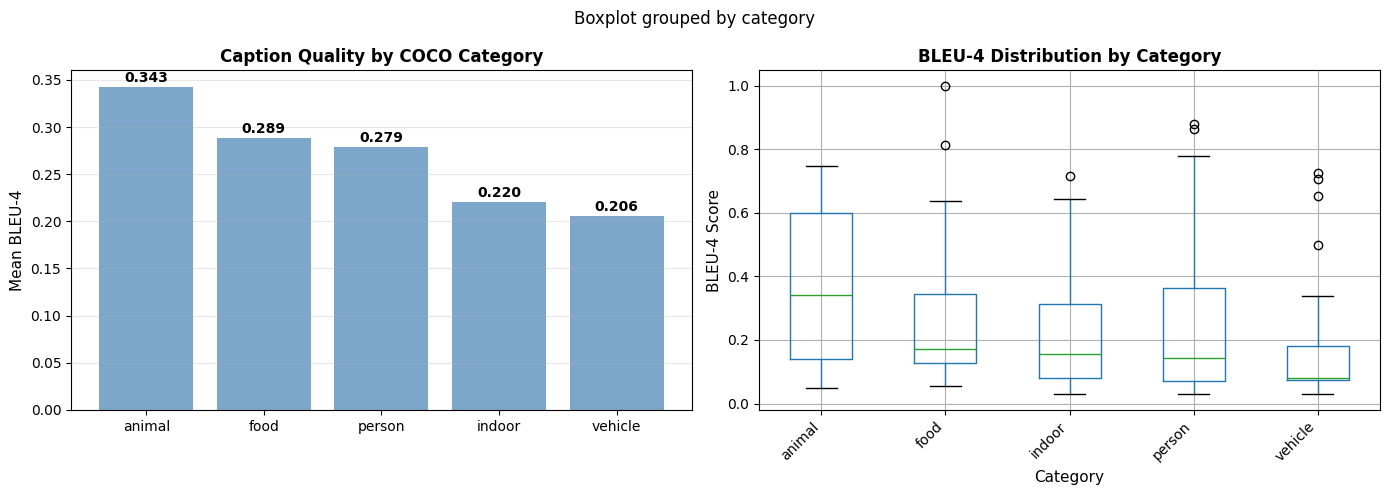


Model Performance Insights:
  Best performance: animal (0.3430)
  Worst performance: vehicle (0.2060)
  Performance gap: 0.1371


In [7]:
# Analyze by category
print("\n=== BLEU-4 Performance by Category ===")
category_stats = df_categories.groupby('category')['bleu_4'].agg(['mean', 'std', 'min', 'max', 'count'])
print(category_stats.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of mean BLEU by category
cat_means = df_categories.groupby('category')['bleu_4'].mean().sort_values(ascending=False)
axes[0].bar(cat_means.index, cat_means.values, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Mean BLEU-4', fontsize=11)
axes[0].set_title('Caption Quality by COCO Category', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(cat_means.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Box plot
df_categories.boxplot(column='bleu_4', by='category', ax=axes[1])
axes[1].set_ylabel('BLEU-4 Score', fontsize=11)
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_title('BLEU-4 Distribution by Category', fontsize=12, fontweight='bold')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Find model biases
print("\nModel Performance Insights:")
best_cat = cat_means.idxmax()
worst_cat = cat_means.idxmin()
print(f"  Best performance: {best_cat} ({cat_means[best_cat]:.4f})")
print(f"  Worst performance: {worst_cat} ({cat_means[worst_cat]:.4f})")
print(f"  Performance gap: {(cat_means[best_cat] - cat_means[worst_cat]):.4f}")

## Wnioski i dalsze kroki (obszerne)
### Podsumowanie ilościowe
- Średnie BLEU‑4 zaobserwowane w tej próbce (20 obrazów na kategorię):
  - *animal*: 0.343
  - *food*: 0.289
  - *person*: 0.279
  - *indoor*: 0.220
  - *vehicle*: 0.206
- Różnica między najlepszą a najgorszą kategorią wynosi około 0.137 w BLEU‑4, co sugeruje zauważalną nierównomierność wydajności.

### Interpretacja wyników
- **Lepsze wyniki dla kategorii *animal* i *food***: prawdopodobnie wynikają z wyraźnych, łatwo rozpoznawalnych cech wizualnych (kształty i tekstury) oraz częstych, jednoznacznych opisów w danych treningowych.
- **Gorsze wyniki dla *vehicle***: możliwe przyczyny to duża wariancja kontekstów (różne typy i kąty), częściowe zasłonięcia, lub fakt, że poprawny opis wymaga rozpoznania atrybutów (kolor, typ), które model pomija.
- **Rozrzut wyników (boxplot)**: obecność outlierów wskazuje, że w niektórych przypadkach model generuje bardzo trafne opisy (wysokie BLEU), ale często brakuje szczegółów lub model wybiera ogólne opisy prowadzące do niskich wartości BLEU.

### Ograniczenia analizy
- Wielkość próbki: 20 obrazów na kategorię to mała próbka; wyniki mają duże odchylenie statystyczne.
- Metoda kategoryzacji: oparta na słowach‑kluczach w referencjach — może błędnie przypisywać obrazy lub pomijać złożone przypadki.
- Metryka: BLEU‑4 ocenia n‑gramy, nie zawsze koreluje z percepcją jakości przez człowieka (np. synonimy, różne poprawne opisy).
- Brak testów statystycznych: potrzebne, aby potwierdzić istotność obserwowanych różnic.

### Dalsze kroki i rekomendacje praktyczne
1. **Skalowanie próbki**: rozszerzyć analizę do większej liczby obrazów (np. 200–1000 na kategorię) i powtórzyć testy; usunąć bias losowego wyboru.  
2. **Weryfikacja jakości kategoryzacji**: poprawić słownik słów‑kluczy lub użyć adnotacji COCO (kategorie obiektów) zamiast heurystyki tekstowej.  
3. **Testy statystyczne**: przeprowadzić testy (np. t‑testy lub testy nieparametryczne) aby ocenić istotność różnic między kategoriami.  
4. **Analiza przyczynowa**: ręczna inspekcja przypadków błędnych i wizualizacja map uwagi (attention) by sprawdzić, czy dekoder skupia się na właściwych regionach.  
5. **Eksperymenty kontrolne**: uruchomić Experiment 9 (freezing encoder) i Experiment 11 (usunięcie mechanizmu uwagi) aby zbadać wpływ fine‑tuningu i uwagi na kategorie, które najwięcej tracą.  
6. **Możliwe ulepszenia modelu**: fine‑tuning enkodera na docelowym zbiorze COCO, lepsza augmentacja danych, lub model z silniejszą uwagą przestrzenną dla małych obiektów.

### Kryteria sukcesu dla rozszerzonej analizy
- Zmniejszenie luki między kategoriami o mierzalny margines (np. <0.05 BLEU) po zastosowaniu fine‑tuningu lub poprawie danych.  
- Poprawa mediany BLEU‑4 i zmniejszenie liczby niskich wyników (tail) w dystrybucji per‑kategoria.  
- Lokalna zgodność uwagi z obiektami istotnymi dla opisu (weryfikowana wizualnie).